## Q4: Concentration of Measure Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
p = 0.7
m = 10000
nu_list = [0.1, 0.05, 0.01, 0.005, 0.001]

### Part (d) — fix n=1000, vary nu

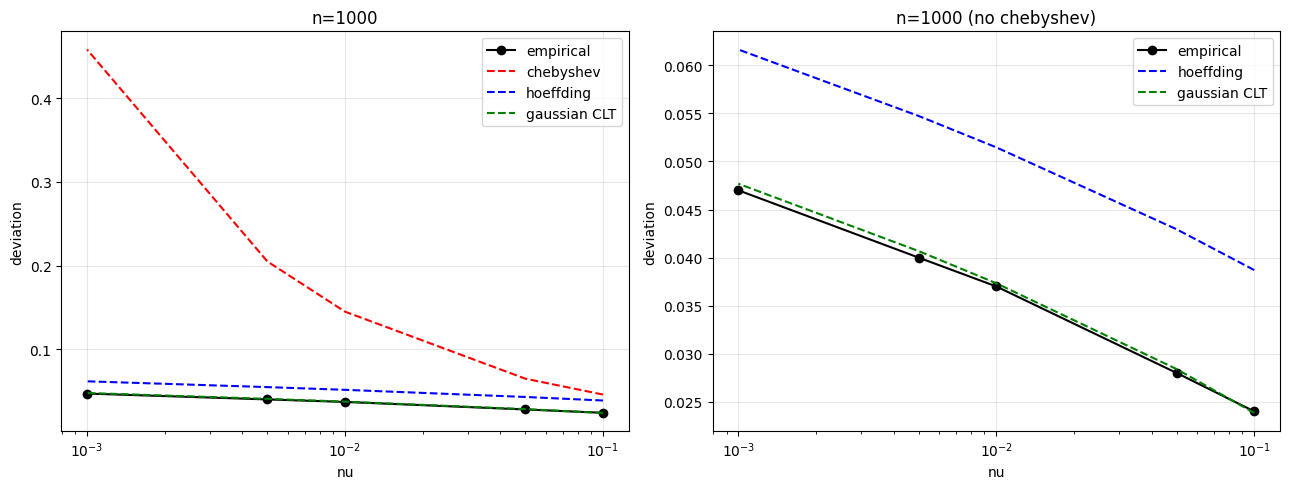

In [3]:
n = 1000

# run m trials
data = np.random.binomial(1, p, size=(m, n))
devs = np.abs(data.mean(axis=1) - p)

emp, cheb, hoeff, gauss = [], [], [], []

for nu in nu_list:
    emp.append(np.quantile(devs, 1 - nu))
    cheb.append(np.sqrt(p*(1-p) / (n*nu)))
    hoeff.append(np.sqrt(np.log(2/nu) / (2*n)))
    gauss.append(norm.ppf(1 - nu/2) * np.sqrt(p*(1-p)/n))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.semilogx(nu_list, emp,   'ko-', label='empirical')
ax1.semilogx(nu_list, cheb,  'r--', label='chebyshev')
ax1.semilogx(nu_list, hoeff, 'b--', label='hoeffding')
ax1.semilogx(nu_list, gauss, 'g--', label='gaussian CLT')
ax1.set_xlabel('nu'); ax1.set_ylabel('deviation')
ax1.set_title('n=1000'); ax1.legend(); ax1.grid(alpha=0.3)

# same without chebyshev to see the detail
ax2.semilogx(nu_list, emp,   'ko-', label='empirical')
ax2.semilogx(nu_list, hoeff, 'b--', label='hoeffding')
ax2.semilogx(nu_list, gauss, 'g--', label='gaussian CLT')
ax2.set_xlabel('nu'); ax2.set_ylabel('deviation')
ax2.set_title('n=1000 (no chebyshev)'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q4d.png', dpi=150)
plt.show()

### Part (e) — fix nu=0.01, vary n

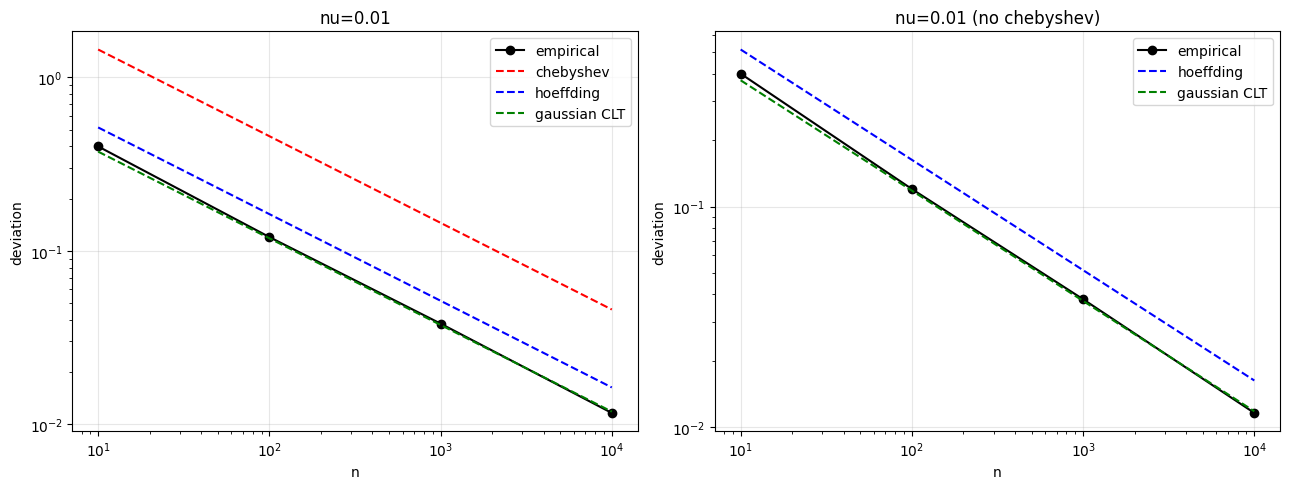

empirical -0.511
chebyshev -0.5
hoeffding -0.5
gaussian -0.5


In [4]:
nu = 0.01
ns = [10, 100, 1000, 10000]

emp2, cheb2, hoeff2, gauss2 = [], [], [], []

for n in ns:
    d = np.random.binomial(1, p, size=(m, n))
    dev = np.abs(d.mean(axis=1) - p)
    emp2.append(np.quantile(dev, 1 - nu))
    cheb2.append(np.sqrt(p*(1-p) / (n*nu)))
    hoeff2.append(np.sqrt(np.log(2/nu) / (2*n)))
    gauss2.append(norm.ppf(1 - nu/2) * np.sqrt(p*(1-p)/n))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.loglog(ns, emp2,   'ko-', label='empirical')
ax1.loglog(ns, cheb2,  'r--', label='chebyshev')
ax1.loglog(ns, hoeff2, 'b--', label='hoeffding')
ax1.loglog(ns, gauss2, 'g--', label='gaussian CLT')
ax1.set_xlabel('n'); ax1.set_ylabel('deviation')
ax1.set_title('nu=0.01'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.loglog(ns, emp2,   'ko-', label='empirical')
ax2.loglog(ns, hoeff2, 'b--', label='hoeffding')
ax2.loglog(ns, gauss2, 'g--', label='gaussian CLT')
ax2.set_xlabel('n'); ax2.set_ylabel('deviation')
ax2.set_title('nu=0.01 (no chebyshev)'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q4e.png', dpi=150)
plt.show()

# slopes should all be around -0.5 (1/sqrt(n) scaling)
for label, vals in zip(['empirical', 'chebyshev', 'hoeffding', 'gaussian'], [emp2, cheb2, hoeff2, gauss2]):
    s, _ = np.polyfit(np.log(ns), np.log(vals), 1)
    print(label, round(s, 3))